# Two classes interacting with each other

# Write OOP classes to handle the following scenarios:

- A user can create and view 2D coordinates
- A user can find out the distance between 2 coordinates
- A user can find the distance of a coordinate from origin
- A user can check if a point lies on a given line
- A user can find the distance between a given 2D point and a given line
- A user can find whether 2 lines intersect or not

In [ ]:
class Point:
  def __init__(self,x,y):
    self.x_cod = x
    self.y_cod = y

  #this is how i want my point objects too look like
  def __str__(self):
    return '<{},{}>'.format(self.x_cod, self.y_cod)

  def euclidean_distance(self, other): #self is x1,y1, other is x2,
    # ((x1-x2)^2 + (y1-y2)^2)**0.5
    return ((self.x_cod - other.x_cod)**2 + (self.y_cod - other.y_cod)**2) ** 0.5

  # meh way
  # def origin_distance(self):
  #   return ((self.x_cod)**2 + (self.y_cod)**2) ** 0.5

  # smarter way
  def origin_distance(self):
    #return self.euclidean_distance(self,Point(0,0)) #dont give self here, automatically the first self will go as an argument
    return self.euclidean_distance(Point(0,0))


# line eqn = Ax + By + C = 0; user will enter values of A, B and C
class Line:

  def __init__(self, A, B, C): # A, B, C in __init__ are parameters;
    self.A = A                 # self.A, self.B, self.C are instance attributes.
    self.B = B                 # The values passed to the parameters are assigned to the instance attributes.
    self.C = C

  def __str__(self):
    return '{}x + {}y + {} = 0'.format(self.A, self.B, self.C)

  # check point lies in a line; input x,y in line eqn. rhs == 0
  def point_on_line(line,point):
    if line.A * point.x_cod + line.B * point.y_cod + line.C == 0:
      return "Lies on the line"
    else:
      return "does not lie on the line"

  # calculate shortest distance b/w a line and point,
  # formula = |Ax1 + By1 + C|/ ((A^2 + B^2)** 0.5)
  def shortest_distance(line, point):
    return abs(line.A * point.x_cod + line.B * point.y_cod + line.C) / (line.A ** 2 + line.B ** 2) ** 0.5

In [ ]:
# 5 distance b/w line and a point

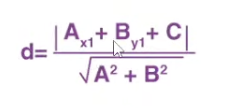

In [ ]:
# 1
p1 = Point(10,10)
p2 = Point(10,10)
print(p1)
print(p2)

<10,10>
<10,10>


In [ ]:
# 2
p1.euclidean_distance(p2)

0.0

In [ ]:
# 3
p1.origin_distance()

14.142135623730951

In [ ]:
# 4
l1 = Line(1, 1, -2)
p1 = Point(1,10)
print(l1)
print(p1)

1x + 1y + -2 = 0
<1,10>


In [ ]:
# 4
l1.point_on_line(p1)

'does not lie on the line'

In [ ]:
# 5

l1.shortest_distance(p1)

6.363961030678928

### How objects access attributes

In [ ]:
class Person:

  def __init__(self,name_input,country_input):
    self.name = name_input
    self.country = country_input

  def greet(self):
    if self.country == 'india':
      print('Namaste',self.name)
    else:
      print('Hello',self.name)


In [ ]:
# how to access attributes
p = Person('nitish','india')

In [ ]:
p.name

'nitish'

In [ ]:
# how to access methods
p.greet()

Namaste nitish


In [ ]:
# what if i try to access non-existent attributes
p.gender

AttributeError: 'Person' object has no attribute 'gender'

### Attribute creation from outside of the class

In [ ]:
p.gender = 'male'

In [ ]:
p.gender

'male'

### Reference Variables

- Reference variables hold the objects
- We can create objects without reference variable as well
- An object can have multiple reference variables
- Assigning a new reference variable to an existing object does not create a new object

In [ ]:
# object without a reference
class Person:

  def __init__(self):
    self.name = 'nitish'
    self.gender = 'male'

p = Person()
q = p

In [ ]:
# Multiple ref
print(id(p))
print(id(q))

138659679933968
138659679933968


# CAUTION: CHANGE IN ONE VARIABLE WILL LEAD TO CHANGE IN THE OTHER REFERENCING THE SAME OBJECT.

## AND THAT IS WE WE CREATE COPY INSTEAD OF DOING A=B

In [ ]:
print(p.name)
print(q.name)
q.name = 'ankit'
print(q.name)
print(p.name)

nitish
nitish
ankit
ankit


## Pass by reference

### First time this is happening
- You can pass whole ass object of a class to a function in python as an input. (Function ko class ke object as an input de rahe.)
- Function can output object of a class. Function output me class ka object diya. till now it was Z, float.

### It is powerful to create an object and give it to a function as an input and get an object as an output. Useful in real life projects

In [ ]:
class Person:

  def __init__(self,name,gender):
    self.name = name
    self.gender = gender

# outside the class -> function
def greet(person):
  print('Hi my name is',person.name,'and I am a',person.gender)
  p1 = Person('ankit','male')
  return p1

p = Person('nitish','male')
x = greet(p)
print(x)
print(x.name)
print(x.gender)

Hi my name is nitish and I am a male
ankit
male


### Notice id same
#### function ko object ni, object ka reference bheja or address.
- when we input objet in a function, technically we send the address of the object, not th eibject itself.

In [ ]:
class Person:

  def __init__(self,name,gender):
    self.name = name
    self.gender = gender

# outside the class -> function
def greet(person):
  print(id(person))
  person.name = 'ankit'
  print(person.name)

p = Person('nitish','male')
print(id(p)) # both id same
greet(p)
print(p.name) # both print ankit because p and person refer to the same object

138659679942944
138659679942944
ankit
ankit


## Object ki mutability

- Objects created in python classes are mutable by default.
- Can be made immutable too.

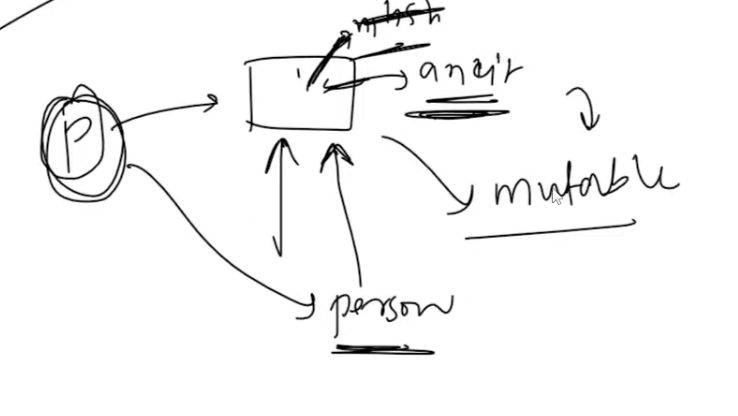

In [ ]:
class Person:

  def __init__(self,name,gender):
    self.name = name
    self.gender = gender

# outside the class -> function
def greet(person):
  person.name = 'ankit'
  return person

p = Person('nitish','male')
print(id(p))
p1 = greet(p)
print(id(p1))

138659679936560
138659679936560


# Encapsulation
- bundling data and methods, protecting them form outside interference

- attributes and its methods are all made pruvate in a class and exposed to the outer world through a protected layer using getter and setter method. This whole process is called encapsulation.

### Standard practice: create 1 getter and setter for each attribute.

### First understand Instance Variable
It's a special variable. It's value differs depending on the opbject.

In [ ]:
# instance var -> python tutor
class Person:

  def __init__(self,name_input,country_input):
    self.name = name_input # instance variable
    self.country = country_input

p1 = Person('nitish','india')
p2 = Person('steve','australia')

In [ ]:
p2.name

'steve'

In [ ]:
p1.name

'nitish'

## Private variable

### In python nothing is truly private: python is for adults


- in python add __ double underscore before variable/ attribute name to make it private

- self.__balance will be saved as _classname__balance in memory

- so even if someone tries to access private variable from outside they can if they know the trick is to write this to acces it _classname__balance

- if outsider writes __balance, this will instead create a new variable.

In [ ]:
 def __init__(self):
    print(id(self))
    self.pin = ''
    self.__balance = 0.       #private attribute name


  def __menu(self):           # private method
    user_input = input("""

### What if situation demands to give access of private varibales while keeping it private?

Possible using the concept: getter and setter method

For every data you have in your class you create 2 methods. Getter and setter.

- Getter: to show private variable's value when accessed from outside the class
- Setter: to change private varible's value from outside.

In [1]:
class Atm:

  # constructor(special function)->superpower ->
  def __init__(self):
    print(id(self))
    self.pin = ''
    self.__balance = 0
    #self.menu()

  def get_balance(self):
    return self.__balance

  def set_balance(self,new_value):
    if type(new_value) == int:     #can insert the logic now to safeguard against malpractices
      self.__balance = new_value
    else:
      print('beta bahot maarenge')

  def __menu(self):
    user_input = input("""
    Hi how can I help you?
    1. Press 1 to create pin
    2. Press 2 to change pin
    3. Press 3 to check balance
    4. Press 4 to withdraw
    5. Anything else to exit
    """)

    if user_input == '1':
      self.create_pin()
    elif user_input == '2':
      self.change_pin()
    elif user_input == '3':
      self.check_balance()
    elif user_input == '4':
      self.withdraw()
    else:
      exit()

  def create_pin(self):
    user_pin = input('enter your pin')
    self.pin = user_pin

    user_balance = int(input('enter balance'))
    self.__balance = user_balance

    print('pin created successfully')

  def change_pin(self):
    old_pin = input('enter old pin')

    if old_pin == self.pin:
      # let him change the pin
      new_pin = input('enter new pin')
      self.pin = new_pin
      print('pin change successful')
    else:
      print('nai karne de sakta re baba')

  def check_balance(self):
    user_pin = input('enter your pin')
    if user_pin == self.pin:
      print('your balance is ',self.__balance)
    else:
      print('chal nikal yahan se')

  def withdraw(self):
    user_pin = input('enter the pin')
    if user_pin == self.pin:
      # allow to withdraw
      amount = int(input('enter the amount'))
      if amount <= self.__balance:
        self.__balance = self.__balance - amount
        print('withdrawl successful.balance is',self.__balance)
      else:
        print('abe garib')
    else:
      print('sale chor')

In [2]:
obj = Atm()

136518143626752


In [3]:
obj.get_balance()

0

In [4]:
obj.set_balance(1000)

In [5]:
obj.withdraw()

enter the pin1234
sale chor


## Collection of Objects

- create objects and store them in list or dict

- useful in applying loops, iterations on objects

In [6]:
# list of objects
class Person:

  def __init__(self,name,gender):
    self.name = name
    self.gender = gender

p1 = Person('nitish','male')
p2 = Person('ankit','male')
p3 = Person('ankita','female')

L = [p1,p2,p3]

for i in L:
  print(i.name,i.gender)

nitish male
ankit male
ankita female


In [7]:
# dict of objects
# list of objects
class Person:

  def __init__(self,name,gender):
    self.name = name
    self.gender = gender

p1 = Person('nitish','male')
p2 = Person('ankit','male')
p3 = Person('ankita','female')

d = {'p1':p1,'p2':p2,'p3':p3}

for i in d:
  print(d[i].gender)

male
male
female


Q Can we store object in a set?


Yes, you can store objects in a set in Python, but there's a crucial condition: the objects must be hashable.

Hashable objects have a __hash__ method and an __eq__ method, and their hash value never changes during their lifetime. Built-in immutable types like numbers, strings, and tuples are hashable by default.
Un-hashable objects (like lists, dictionaries, and custom class instances by default) cannot be directly stored in a set because sets rely on hash values for efficient lookup and to ensure uniqueness.
If you want to store instances of a custom class in a set, you'll need to implement the __hash__ and __eq__ methods in your class, ensuring that objects considered equal have the same hash value.

## Statis variable and static method

## Static Variables(Vs Instance variables)

### Difference b/w static and instance variable

- static for class, instance for object

- static value same for all objects, instance value differs for every object

- fetch static: classname.variablename, fetch instance: objectname.variablename

- static declared before init, instance declared after init

- eg, collegeName static, studentName instance


### getter setter applied on static variable too

In [9]:
 class Atm:

  __counter = 1

  # constructor(special function)->superpower ->
  def __init__(self):
    print(id(self))
    self.pin = ''
    self.__balance = 0
    self.cid = Atm.__counter
    Atm.__counter = Atm.__counter + 1
    #self.menu()

  # utility functions          dont need objects
  @staticmethod               # staticmethod, no need to use self.
  def get_counter():
    return Atm.__counter


  def get_balance(self):
    return self.__balance

  def set_balance(self,new_value):
    if type(new_value) == int:
      self.__balance = new_value
    else:
      print('beta bahot maarenge')

  def __menu(self):
    user_input = input("""
    Hi how can I help you?
    1. Press 1 to create pin
    2. Press 2 to change pin
    3. Press 3 to check balance
    4. Press 4 to withdraw
    5. Anything else to exit
    """)

    if user_input == '1':
      self.create_pin()
    elif user_input == '2':
      self.change_pin()
    elif user_input == '3':
      self.check_balance()
    elif user_input == '4':
      self.withdraw()
    else:
      exit()

  def create_pin(self):
    user_pin = input('enter your pin')
    self.pin = user_pin

    user_balance = int(input('enter balance'))
    self.__balance = user_balance

    print('pin created successfully')

  def change_pin(self):
    old_pin = input('enter old pin')

    if old_pin == self.pin:
      # let him change the pin
      new_pin = input('enter new pin')
      self.pin = new_pin
      print('pin change successful')
    else:
      print('nai karne de sakta re baba')

  def check_balance(self):
    user_pin = input('enter your pin')
    if user_pin == self.pin:
      print('your balance is ',self.__balance)
    else:
      print('chal nikal yahan se')

  def withdraw(self):
    user_pin = input('enter the pin')
    if user_pin == self.pin:
      # allow to withdraw
      amount = int(input('enter the amount'))
      if amount <= self.__balance:
        self.__balance = self.__balance - amount
        print('withdrawl successful.balance is',self.__balance)
      else:
        print('abe garib')
    else:
      print('sale chor')

In [2]:
c1 = Atm()

133578983010912


In [3]:
Atm.get_counter()

2

In [4]:
c3 = Atm()

133578983001936


In [5]:
c3.cid

2

In [8]:
Atm._Atm__counter

3